In [14]:
# package
from transformers import ViTForImageClassification, ViTImageProcessor
from transformers import AutoProcessor, AutoModelForImageTextToText
from pathlib import Path
from collections import Counter
import random
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch import device
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from tqdm import tqdm
from skimage.morphology import skeletonize
from scipy.ndimage import distance_transform_edt
from pytorch_grad_cam import (
    GradCAM,
    ScoreCAM,
    GradCAMPlusPlus,
    AblationCAM,
    XGradCAM,
    EigenCAM,
    LayerCAM,
    FullGrad,
)
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

load dataset -->Vit style --> 注意力+饼图 --> 图片matching --> skeleton+对齐分析 --> LLM反馈

In [15]:
# 在temp_pic里创建一个新的文件夹来存储处理后的图片
import time
# YYMMDD_HHMMSS
timestamp = time.strftime("%y%m%d_%H%M%S")
processed_dir = f"temp_pic/processed_{timestamp}"
Path(processed_dir).mkdir(parents=True, exist_ok=True)

In [16]:
user_upload_path = "net.png"
user_set_style = "yzq"
user_style_recog = []
recog_char = None
match_img_path = None
match_score = None
top_k_similar = 3

# load dataset

In [17]:
# 加载 classification 数据（calli-kaggle）
data_root = Path("calli-kaggle/data/data")
if not data_root.exists():
    raise FileNotFoundError(f"未找到数据目录: {data_root.resolve()}")

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

def load_split(split_name: str):
    split_dir = data_root / split_name
    if not split_dir.exists():
        raise FileNotFoundError(f"未找到 split 目录: {split_dir}")

    class_names = sorted([p.name for p in split_dir.iterdir() if p.is_dir()])
    class_to_idx = {name: i for i, name in enumerate(class_names)}

    samples = []
    for class_name in class_names:
        class_dir = split_dir / class_name
        for p in class_dir.rglob("*"):
            if p.is_file() and p.suffix.lower() in IMG_EXTS:
                samples.append((str(p), class_to_idx[class_name], class_name))

    return class_names, class_to_idx, samples

train_classes, class_to_idx, train_samples = load_split("train")
test_classes, _, test_samples = load_split("test")

# train/test 类别一致性检查
if train_classes != test_classes:
    print("警告: train 和 test 的类别列表不一致")
else:
    print(f"类别数: {len(train_classes)}")
    print(f"类别名: {train_classes}")

train_counts = Counter([label_name for _, _, label_name in train_samples])
test_counts = Counter([label_name for _, _, label_name in test_samples])

print(f"train 样本数: {len(train_samples)}")
print(f"test 样本数: {len(test_samples)}")

print("\n各类别样本数（train / test）:")
for c in train_classes:
    print(f"{c:>6}: {train_counts.get(c, 0):>4} / {test_counts.get(c, 0):>4}")

# 随机查看几条样本路径
preview_n = min(5, len(train_samples))
print("\ntrain 样本示例:")
for path, label_idx, label_name in random.sample(train_samples, k=preview_n):
    print(f"label={label_idx:>2} ({label_name}) | {path}")

# 如果你后续要喂给模型，可直接使用：
X_train = [s[0] for s in train_samples]
y_train = [s[1] for s in train_samples]
X_test = [s[0] for s in test_samples]
y_test = [s[1] for s in test_samples]

print("\n已生成: X_train, y_train, X_test, y_test, class_to_idx")

类别数: 20
类别名: ['bdsr', 'csl', 'fwq', 'gj', 'htj', 'hy', 'lgq', 'lqs', 'lx', 'mf', 'mzd', 'oyx', 'sgt', 'shz', 'smh', 'wxz', 'wzm', 'yyr', 'yzq', 'zmf']
train 样本数: 84022
test 样本数: 21007

各类别样本数（train / test）:
  bdsr: 1588 /  397
   csl:  860 /  215
   fwq: 5410 / 1353
    gj: 5410 / 1353
   htj: 5371 / 1343
    hy: 2665 /  666
   lgq: 5410 / 1353
   lqs: 5406 / 1351
    lx: 5410 / 1353
    mf: 5410 / 1353
   mzd: 5410 / 1353
   oyx: 2808 /  702
   sgt: 5001 / 1250
   shz: 5410 / 1353
   smh: 1014 /  253
   wxz: 5393 / 1348
   wzm: 3621 /  905
   yyr: 5410 / 1353
   yzq: 5405 / 1351
   zmf: 1610 /  402

train 样本示例:
label= 6 (lgq) | calli-kaggle/data/data/train/lgq/2059.jpg
label=10 (mzd) | calli-kaggle/data/data/train/mzd/3307.jpg
label= 8 (lx) | calli-kaggle/data/data/train/lx/4153.jpg
label= 8 (lx) | calli-kaggle/data/data/train/lx/0305.jpg
label=13 (shz) | calli-kaggle/data/data/train/shz/1645.jpg

已生成: X_train, y_train, X_test, y_test, class_to_idx


In [18]:
style_summary_df = pd.read_csv("calli-kaggle/Summary.csv")
master_match_dict = dict(zip(style_summary_df["Label"], style_summary_df["Calligrapher Name"]))
print(master_match_dict)
print(class_to_idx)
total_classes = len(master_match_dict)
print(f"总类别数: {total_classes}")

{'wxz': '王羲之', 'yzq': '颜真卿', 'lgq': '柳公权', 'sgt': '孙过庭', 'smh': '沙孟海', 'mf': '米芾', 'htj': '黄庭坚', 'oyx': '欧阳询', 'zmf': '赵孟頫', 'csl': '褚遂良', 'wzm': '文征明', 'lqs': '梁秋生', 'yyr': '于右任', 'hy': '弘一', 'bdsr': '八大山人', 'fwq': '范文强', 'gj': '管峻', 'shz': '宋徽宗', 'mzd': '毛泽东', 'lx': '鲁迅'}
{'bdsr': 0, 'csl': 1, 'fwq': 2, 'gj': 3, 'htj': 4, 'hy': 5, 'lgq': 6, 'lqs': 7, 'lx': 8, 'mf': 9, 'mzd': 10, 'oyx': 11, 'sgt': 12, 'shz': 13, 'smh': 14, 'wxz': 15, 'wzm': 16, 'yyr': 17, 'yzq': 18, 'zmf': 19}
总类别数: 20


# Vit Style

In [19]:
from transformers import ViTForImageClassification, ViTImageProcessor

save_dir = "./vit_calligraphy_best"

processor = ViTImageProcessor.from_pretrained(save_dir)
model = ViTForImageClassification.from_pretrained(save_dir)

device = device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Using device: mps


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [20]:
# style classification
def show_prediction_pie(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt")
    pixel_values = inputs["pixel_values"].to(device)
    model.eval()
    with torch.no_grad():
        outputs = model(pixel_values=pixel_values)
        logits = outputs.logits
        pred_idx = torch.argmax(logits, dim=1).item()
        pred_label = train_classes[pred_idx]
        probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy() * 100
        # 画图显示概率分布
        # ===== Top-K 饼图（清晰版）=====
        topk = 6  # 可自己调整

        # 取前K个最大概率
        indices = probs.argsort()[-topk:][::-1]

        top_probs = probs[indices]
        top_labels = [master_match_dict.get(train_classes[i], train_classes[i]) for i in indices]

        # 在 user_style_recog 里添加预测的 top3 书法家，同时组织函数返回值
        user_style_recog.clear()  # 清空之前的记录
        top3_calligrapher_probs = []
        for i in range(min(3, len(top_labels))):
            prob = float(top_probs[i])
            user_style_recog.append([user_set_style, top_labels[i], prob])
            top3_calligrapher_probs.append({
                "style": user_set_style,
                "calligrapher": top_labels[i],
                "probability": prob,
            })

        # 剩余合并为“其他”
        other_prob = 100 - top_probs.sum()
        if other_prob > 0:
            top_probs = list(top_probs) + [other_prob]
            top_labels = top_labels + ["其他"]

        # 画图
        plt.figure(figsize=(8, 8))
        plt.rcParams["font.sans-serif"] = ["SimSun", "Microsoft YaHei", "SimHei", "SimSong"]
        plt.rcParams["axes.unicode_minus"] = False

        plt.pie(
            top_probs,
            labels=top_labels,
            autopct="%1.1f%%",
            startangle=140
        )

        plt.title("Top预测概率分布")
        plt.show()

        print(f"预测类别: {pred_label} (index: {pred_idx})")
        print(f"对应书法家: {master_match_dict.get(pred_label, '未知')}")

        return top3_calligrapher_probs

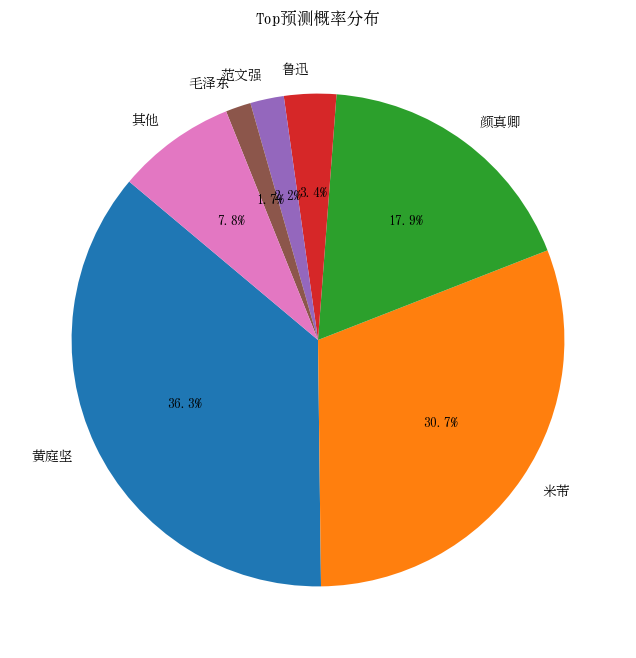

预测类别: htj (index: 4)
对应书法家: 黄庭坚
top3 书法家概率: [{'style': 'yzq', 'calligrapher': '黄庭坚', 'probability': 36.3057746887207}, {'style': 'yzq', 'calligrapher': '米芾', 'probability': 30.733112335205078}, {'style': 'yzq', 'calligrapher': '颜真卿', 'probability': 17.873443603515625}]


In [21]:
top3_calligrapher_probs = show_prediction_pie(user_upload_path)
print("top3 书法家概率:", top3_calligrapher_probs)

# 注意力

In [22]:
CAM_METHODS = {
    "gradcam": GradCAM,
    "scorecam": ScoreCAM,
    "gradcam++": GradCAMPlusPlus,
    "ablationcam": AblationCAM,
    "xgradcam": XGradCAM,
    "eigencam": EigenCAM,
    "layercam": LayerCAM,
    "fullgrad": FullGrad,
}


class ViTLogitsWrapper(torch.nn.Module):
    """Wrap HuggingFace ViT to return logits tensor only for CAM libs."""

    def __init__(self, hf_model):
        super().__init__()
        self.hf_model = hf_model

    def forward(self, x):
        return self.hf_model(pixel_values=x).logits


def reshape_transform(tensor):
    """ViT token [B, N, C] -> [B, C, H, W] for CAM."""
    tokens = tensor[:, 1:, :]  # remove cls token
    n = tokens.shape[1]
    side = int(np.sqrt(n))
    if side * side != n:
        raise ValueError(f"Token count {n} is not a perfect square.")
    return tokens.reshape(tensor.size(0), side, side, tensor.size(2)).permute(0, 3, 1, 2)


def _resolve_vit_layer(layer_idx, norm_pos="after"):
    """Get HuggingFace ViT encoder layer norm module by index."""
    layer = model.vit.encoder.layer[layer_idx]
    if norm_pos == "after":
        return layer.layernorm_after
    if norm_pos == "before":
        return layer.layernorm_before
    raise ValueError("norm_pos must be 'after' or 'before'")


def _normalize_weights(weights, n_layers):
    if weights is None:
        return np.ones(n_layers, dtype=np.float32) / n_layers
    weights = np.array(weights, dtype=np.float32)
    if len(weights) != n_layers:
        raise ValueError(f"layer_weights length ({len(weights)}) must equal layer_indices length ({n_layers})")
    s = float(weights.sum())
    if abs(s) < 1e-12:
        raise ValueError("layer_weights sum cannot be 0")
    return weights / s


def plot_vit_cam(
    image_path,
    cam_method="gradcam",
    layer_indices=(-2,),
    layer_weights=None,
    norm_pos="after",
    target_idx=None,
    save_path=True,
    show=True,
):
    """
    生成 ViT 热力图（支持多层加权融合）。

    Parameters
    ----------
    image_path : str
        输入图片路径。
    cam_method : str
        CAM 方法名，支持: gradcam, scorecam, gradcam++, ablationcam, xgradcam, eigencam, layercam, fullgrad。
    layer_indices : tuple/list[int]
        指定使用哪些 Transformer 层，例如 (-1,), (-2,), (-3, -2, -1)。
    layer_weights : tuple/list[float] or None
        对应层系数。None 表示均匀加权。
    norm_pos : str
        选哪一个 LN: 'after' 或 'before'。
    target_idx : int or None
        目标类别索引。None 表示模型预测类别。
    save_path : str
        保存热力图文件路径。
    show : bool
        是否显示图像。
    """
    device = next(model.parameters()).device
    model.eval()

    cam_model = ViTLogitsWrapper(model).to(device)
    cam_model.eval()

    # Prepare image
    pil_img = Image.open(image_path).convert("RGB")
    size_cfg = processor.size
    if isinstance(size_cfg, dict):
        h = size_cfg.get("height", 224)
        w = size_cfg.get("width", h)
    else:
        h = w = int(size_cfg)

    vis_rgb = np.array(pil_img.resize((w, h))).astype(np.float32) / 255.0
    input_tensor = processor(images=pil_img, return_tensors="pt")["pixel_values"].to(device)

    # Predict class if needed
    with torch.no_grad():
        logits = cam_model(input_tensor)
        pred_idx = int(torch.argmax(logits, dim=1).item())
    if target_idx is None:
        target_idx = pred_idx

    # Resolve method and layers
    m = cam_method.lower()
    if m not in CAM_METHODS:
        raise ValueError(f"Unsupported cam_method={cam_method}. Choose from: {list(CAM_METHODS.keys())}")
    cam_cls = CAM_METHODS[m]

    layer_indices = list(layer_indices)
    target_layers = [_resolve_vit_layer(i, norm_pos=norm_pos) for i in layer_indices]
    weights = _normalize_weights(layer_weights, len(target_layers))

    # Compute per-layer CAM then weighted fusion
    targets = [ClassifierOutputTarget(target_idx)]
    cams = []
    for layer, lw in zip(target_layers, weights):
        with cam_cls(model=cam_model, target_layers=[layer], reshape_transform=reshape_transform) as cam:
            gcam = cam(input_tensor=input_tensor, targets=targets)[0]
        cams.append(lw * gcam)

    fused_cam = np.sum(cams, axis=0)
    fused_cam = np.maximum(fused_cam, 0)
    fused_cam = fused_cam - fused_cam.min()
    fused_cam = fused_cam / (fused_cam.max() + 1e-8)

    visualization = show_cam_on_image(vis_rgb, fused_cam, use_rgb=True)
    if save_path == True:
        output_path = Path(processed_dir) / "concentration.jpg"
        cv2.imwrite(str(output_path), cv2.cvtColor(visualization, cv2.COLOR_RGB2BGR))

    # Text output
    pred_label = train_classes[pred_idx] if pred_idx < len(train_classes) else str(pred_idx)
    tgt_label = train_classes[target_idx] if target_idx < len(train_classes) else str(target_idx)

    print(f"CAM method: {cam_method}")
    print(f"Layer indices: {layer_indices}")
    print(f"Layer weights(norm): {weights.tolist()}")
    print(f"Predicted class: {pred_label} (idx={pred_idx})")
    print(f"Target class: {tgt_label} (idx={target_idx})")
    print(f"Calligrapher: {master_match_dict.get(tgt_label, '未知')}")
    if save_path == True:
        print(f"Saved to: {output_path}")

    if show:
        plt.figure(figsize=(4, 4))
        plt.imshow(vis_rgb)
        plt.title("Original")
        plt.axis("off")
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(4, 4))
        plt.imshow(visualization)
        plt.title(f"{cam_method} | layers={layer_indices}")
        plt.axis("off")
        plt.tight_layout()
        plt.show()

    return
    # return {
    #     "fused_cam": fused_cam,
    #     "visualization": visualization,
    #     "pred_idx": pred_idx,
    #     "target_idx": target_idx,
    #     "layer_indices": layer_indices,
    #     "layer_weights": weights,
    # }


# ===== 用法示例 =====
# 单层（默认）
# out = plot_vit_cam("net.png")

# 指定某一层（比如倒数第1层）
# out = plot_vit_cam("net.png", layer_indices=(-1,))

# 多层融合，并指定层系数（会自动归一化）

CAM method: gradcam++
Layer indices: [-2, -3, -4]
Layer weights(norm): [0.25, 0.25, 0.5]
Predicted class: htj (idx=4)
Target class: htj (idx=4)
Calligrapher: 黄庭坚
Saved to: temp_pic/processed_260426_203134/concentration.jpg


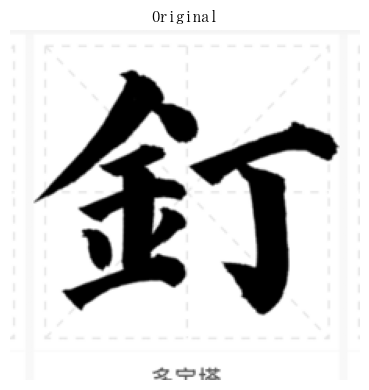

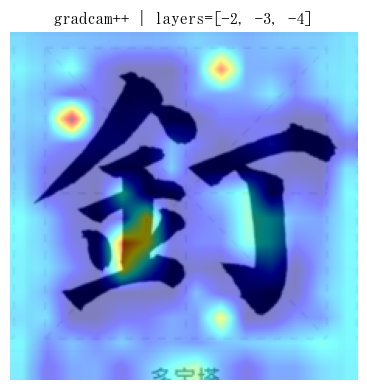

In [23]:
plot_vit_cam(
    image_path="net.png",
    cam_method="gradcam++",
    layer_indices=(-2, -3, -4),
    layer_weights=(0.5, 0.5, 1),
    norm_pos="after",
    target_idx=None,
    show=True,
)

# picture matching

use LLM to recognize the character in the image and seek the matching result.

In [24]:
processor_b = AutoProcessor.from_pretrained("Qwen/Qwen3-VL-8B-Instruct")
model_b = AutoModelForImageTextToText.from_pretrained("Qwen/Qwen3-VL-8B-Instruct")
model_b.to(device)

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

Qwen3VLForConditionalGeneration(
  (model): Qwen3VLModel(
    (visual): Qwen3VLVisionModel(
      (patch_embed): Qwen3VLVisionPatchEmbed(
        (proj): Conv3d(3, 1152, kernel_size=(2, 16, 16), stride=(2, 16, 16))
      )
      (pos_embed): Embedding(2304, 1152)
      (rotary_pos_emb): Qwen3VLVisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-26): 27 x Qwen3VLVisionBlock(
          (norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
          (norm2): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
          (attn): Qwen3VLVisionAttention(
            (qkv): Linear(in_features=1152, out_features=3456, bias=True)
            (proj): Linear(in_features=1152, out_features=1152, bias=True)
          )
          (mlp): Qwen3VLVisionMLP(
            (linear_fc1): Linear(in_features=1152, out_features=4304, bias=True)
            (linear_fc2): Linear(in_features=4304, out_features=1152, bias=True)
            (act_fn): GELUTanh()
          )
        )
      )
 

In [25]:
# recog function
from transformers import AutoProcessor, AutoModelForImageTextToText
def character_recognition(image_path):
    image = Image.open(image_path).convert("RGB")
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": "请识别图中的书法字，并用一个简体字回复是什么"},
            ]
        },
    ]
    inputs = processor_b.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    ).to(model_b.device)

    outputs = model_b.generate(**inputs, max_new_tokens=200)
    response = processor_b.decode(outputs[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True)
    print(response)
    return response


In [26]:
recog_char = character_recognition("net.png")

钉


In [27]:
# yzq_pseudo_labels.csv
def pic_seeker(target_style, target_char):
    # 匹配pseudo label
    csv_name = f"{target_style}_pseudo_labels.csv"
    pseudo_df = pd.read_csv(csv_name)
    matched_rows = pseudo_df[pseudo_df["pseudo_label"] == target_char]
    if matched_rows.empty:
        print(f"未找到匹配的图片: style={target_style}, char={target_char}")
        return None
    else:
        img_path = matched_rows.iloc[0]["path"]
        print(f"找到匹配的图片: {img_path}")
        return img_path

In [28]:
match_img_path = pic_seeker(user_set_style, recog_char)

找到匹配的图片: calli-kaggle\data\data\test\yzq\5423.jpg


# skeleton + overlap

## skeleton extraction

In [29]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.morphology import skeletonize
from scipy.ndimage import distance_transform_edt


def _read_binary(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"无法读取图片，请检查路径: {image_path}")

    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    if binary[0, 0] == 255:
        binary = cv2.bitwise_not(binary)

    return binary


def _adaptive_canvas_size(binary_images, padding_ratio=0.15, min_size=256, max_size=768, align_to=16):
    longest = 0

    for binary in binary_images:
        points = cv2.findNonZero(binary)
        if points is None:
            continue
        _, _, w, h = cv2.boundingRect(points)
        longest = max(longest, w, h)

    if longest == 0:
        size = min_size
    else:
        size = int(np.ceil(longest * (1 + 2 * padding_ratio)))
        size = max(min_size, min(max_size, size))

    return int(np.ceil(size / align_to) * align_to)


def get_centroid(binary_img):
    m = cv2.moments(binary_img)
    if m["m00"] == 0:
        h, w = binary_img.shape
        return w // 2, h // 2

    return int(m["m10"] / m["m00"]), int(m["m01"] / m["m00"])


def shift_image(binary_img, dx, dy):
    h, w = binary_img.shape
    m = np.float32([[1, 0, dx], [0, 1, dy]])
    return cv2.warpAffine(binary_img, m, (w, h), flags=cv2.INTER_NEAREST, borderValue=0)


def centroid_align(reference_binary, target_binary):
    ref_cx, ref_cy = get_centroid(reference_binary)
    tar_cx, tar_cy = get_centroid(target_binary)

    dx = ref_cx - tar_cx
    dy = ref_cy - tar_cy

    aligned = shift_image(target_binary, dx, dy)
    return aligned, dx, dy


def overlap_score(ref_skel, user_skel, tolerance=10):
    ref_bool = ref_skel > 0
    user_bool = user_skel > 0

    if ref_bool.sum() == 0 or user_bool.sum() == 0:
        return 0.0

    dist_to_ref = distance_transform_edt(~ref_bool)
    dist_to_user = distance_transform_edt(~user_bool)

    user_distances = dist_to_ref[user_bool]
    ref_distances = dist_to_user[ref_bool]

    user_soft = np.exp(-(user_distances ** 2) / (2 * (tolerance ** 2)))
    ref_soft = np.exp(-(ref_distances ** 2) / (2 * (tolerance ** 2)))

    return float(0.5 * user_soft.mean() + 0.5 * ref_soft.mean())


def refine_alignment_by_search(ref_skel, user_skel, search_radius=12, tolerance=10):
    best_score = -1.0
    best_dx = 0
    best_dy = 0
    best_aligned = user_skel.copy()

    for dy in range(-search_radius, search_radius + 1):
        for dx in range(-search_radius, search_radius + 1):
            shifted = shift_image(user_skel, dx, dy)
            score = overlap_score(ref_skel, shifted, tolerance=tolerance)

            if score > best_score:
                best_score = score
                best_dx = dx
                best_dy = dy
                best_aligned = shifted

    return best_aligned, best_dx, best_dy, best_score


def remove_small_noise_and_watermark(binary, min_area_ratio=0.002):
    """
    去掉小噪声、小水印。
    binary: 白字黑底
    """
    h, w = binary.shape
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)

    cleaned = np.zeros_like(binary)
    total_area = h * w

    for i in range(1, num_labels):
        x, y, bw, bh, area = stats[i]

        area_ratio = area / total_area

        # 去掉很小的组件
        if area_ratio < min_area_ratio:
            continue

        # 去掉底部小水印：位置很靠下，而且高度较小
        if y > h * 0.75 and bh < h * 0.15:
            continue

        cleaned[labels == i] = 255

    return cleaned


def preprocess_and_align_clean(image_path, canvas_size=256, padding_ratio=0.15):
    binary = _read_binary(str(image_path))

    # 新增：去水印 / 小噪声
    binary = remove_small_noise_and_watermark(binary)

    points = cv2.findNonZero(binary)
    if points is None:
        return np.zeros((canvas_size, canvas_size), dtype=np.uint8)

    x, y, w, h = cv2.boundingRect(points)
    subject = binary[y:y+h, x:x+w]

    target_side = int(canvas_size * (1 - 2 * padding_ratio))
    scale = min(target_side / max(w, 1), target_side / max(h, 1))

    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    resized = cv2.resize(subject, (new_w, new_h), interpolation=cv2.INTER_NEAREST)

    canvas = np.zeros((canvas_size, canvas_size), dtype=np.uint8)
    sx = (canvas_size - new_w) // 2
    sy = (canvas_size - new_h) // 2
    canvas[sy:sy+new_h, sx:sx+new_w] = resized

    return canvas

def evaluate_skeleton(std_aligned, stu_aligned, tolerance_ratio=0.02, min_tolerance=3):
    std_skel = (skeletonize(std_aligned > 0) * 255).astype(np.uint8)
    stu_skel = (skeletonize(stu_aligned > 0) * 255).astype(np.uint8)

    canvas_size = std_aligned.shape[0]
    tolerance_pixels = max(min_tolerance, int(round(canvas_size * tolerance_ratio)))
    kernel = np.ones((tolerance_pixels, tolerance_pixels), np.uint8)

    std_tolerance_zone = cv2.dilate(std_skel, kernel, iterations=1)

    errors = cv2.bitwise_and(stu_skel, cv2.bitwise_not(std_tolerance_zone))
    correct = cv2.bitwise_and(stu_skel, std_tolerance_zone)

    total_stu_pixels = np.count_nonzero(stu_skel)
    error_pixels = np.count_nonzero(errors)

    if total_stu_pixels == 0:
        score = 0
    else:
        score = max(0, 100 - (error_pixels / total_stu_pixels) * 200)

    output_vis = np.zeros((canvas_size, canvas_size, 3), dtype=np.uint8)
    output_vis[std_skel > 0] = [0, 180, 0]
    output_vis[correct > 0] = [255, 255, 255]
    output_vis[errors > 0] = [255, 0, 0]

    vis_kernel = np.ones((2, 2), np.uint8)
    output_vis = cv2.dilate(output_vis, vis_kernel, iterations=1)

    return std_skel, stu_skel, output_vis, score


def generate_normalized_evaluation(
    std_path,
    stu_path,
    canvas_size='auto',
    padding_ratio=0.15,
    tolerance_ratio=0.02,
    search_radius_ratio=0.03
):
    std_bin = _read_binary(std_path)
    stu_bin = _read_binary(stu_path)

    if canvas_size == 'auto':
        canvas_size = _adaptive_canvas_size([std_bin, stu_bin], padding_ratio=padding_ratio)

    std_aligned = preprocess_and_align_clean(std_path, canvas_size=canvas_size, padding_ratio=padding_ratio)
    stu_aligned = preprocess_and_align_clean(stu_path, canvas_size=canvas_size, padding_ratio=padding_ratio)

    std_skel = (skeletonize(std_aligned > 0) * 255).astype(np.uint8)
    stu_skel = (skeletonize(stu_aligned > 0) * 255).astype(np.uint8)

    stu_skel_centroid, coarse_dx, coarse_dy = centroid_align(std_skel, stu_skel)

    search_radius = max(4, int(round(canvas_size * search_radius_ratio)))
    soft_tolerance = max(3, int(round(canvas_size * tolerance_ratio)))

    _, fine_dx, fine_dy, align_score = refine_alignment_by_search(
        std_skel,
        stu_skel_centroid,
        search_radius=search_radius,
        tolerance=soft_tolerance
    )

    total_dx = coarse_dx + fine_dx
    total_dy = coarse_dy + fine_dy
    stu_aligned_refined = shift_image(stu_aligned, total_dx, total_dy)

    tolerance_pixels = max(3, int(round(canvas_size * tolerance_ratio)))
    kernel = np.ones((tolerance_pixels, tolerance_pixels), np.uint8)

    std_safe_zone = cv2.dilate(std_aligned, kernel, iterations=1)
    errors = cv2.bitwise_and(stu_aligned_refined, cv2.bitwise_not(std_safe_zone))

    total_stu_pixels = np.count_nonzero(stu_aligned_refined)
    error_pixels = np.count_nonzero(errors)

    score = max(0, 100 - (error_pixels / total_stu_pixels) * 200) if total_stu_pixels > 0 else 0

    final_canvas = np.ones((canvas_size, canvas_size, 3), dtype=np.uint8) * 255
    final_canvas[std_aligned > 0] = [220, 220, 220]
    final_canvas[stu_aligned_refined > 0] = [30, 30, 30]
    final_canvas[errors > 0] = [255, 0, 0]

    return std_aligned, stu_aligned_refined, final_canvas, score, canvas_size, total_dx, total_dy, align_score


    for img_path in tqdm(image_paths, desc="Comparing with centroid align"):
        try:
            std_aligned = preprocess_and_align_clean(
                str(img_path),
                canvas_size=canvas_size,
                padding_ratio=padding_ratio
            )

            std_skel = (skeletonize(std_aligned > 0) * 255).astype(np.uint8)

            # 只保留质心粗对齐，不做搜索 refine
            stu_skel_aligned, dx, dy = centroid_align(std_skel, stu_skel_base)
            stu_aligned = shift_image(stu_base, dx, dy)

            std_tolerance_zone = cv2.dilate(std_skel, kernel, iterations=1)

            correct = cv2.bitwise_and(stu_skel_aligned, std_tolerance_zone)
            errors = cv2.bitwise_and(
                stu_skel_aligned,
                cv2.bitwise_not(std_tolerance_zone)
            )

            total_stu_pixels = np.count_nonzero(stu_skel_aligned)
            error_pixels = np.count_nonzero(errors)
            correct_pixels = np.count_nonzero(correct)

            if total_stu_pixels == 0:
                score = 0
            else:
                precision_score = correct_pixels / total_stu_pixels * 100
                penalty_score = error_pixels / total_stu_pixels * 100
                score = max(0, precision_score - 0.5 * penalty_score)

            output_vis = np.ones((canvas_size, canvas_size, 3), dtype=np.uint8) * 255
            output_vis[std_skel > 0] = [180, 180, 180]
            output_vis[correct > 0] = [0, 0, 0]
            output_vis[errors > 0] = [255, 0, 0]

            results.append({
                "path": str(img_path),
                "score": score,
                "canvas_size": canvas_size,
                "dx": dx,
                "dy": dy,
                "std_aligned": std_aligned,
                "stu_aligned": stu_aligned,
                "result_canvas": output_vis,
                "correct_pixels": correct_pixels,
                "error_pixels": error_pixels
            })

        except Exception as e:
            print(f"跳过 {img_path.name}: {e}")

    if len(results) == 0:
        raise ValueError("所有图片都对比失败，请检查图片格式或路径。")

    results = sorted(results, key=lambda x: x["score"], reverse=True)
    best = results[0]

    print("=" * 70)
    print("🏆 Best Match With Centroid Align Only")
    print(f"File: {best['path']}")
    print(f"Score: {best['score']:.2f} / 100")
    print(f"Canvas Size: {best['canvas_size']}")
    print(f"Shift: dx={best['dx']}, dy={best['dy']}")
    print("=" * 70)

    print("\nTop Results:")
    for i, r in enumerate(results[:top_k], start=1):
        print(f"{i}. {Path(r['path']).name} | Score: {r['score']:.2f}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(best["std_aligned"], cmap="gray")
    axes[0].set_title("Best Standard Image")
    axes[0].axis("off")

    axes[1].imshow(best["stu_aligned"], cmap="gray")
    axes[1].set_title("Uploaded Image After Centroid Align")
    axes[1].axis("off")

    axes[2].imshow(best["result_canvas"])
    axes[2].set_title(f"Result | Score: {best['score']:.2f}")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    return best, results

def fast_rough_score(std_img, stu_img):
    std = std_img > 0
    stu = stu_img > 0

    inter = np.logical_and(std, stu).sum()
    union = np.logical_or(std, stu).sum()
    iou = inter / (union + 1e-6)

    std_h = std.sum(axis=1).astype(np.float32)
    stu_h = stu.sum(axis=1).astype(np.float32)
    std_v = std.sum(axis=0).astype(np.float32)
    stu_v = stu.sum(axis=0).astype(np.float32)

    std_h = std_h / (np.linalg.norm(std_h) + 1e-6)
    stu_h = stu_h / (np.linalg.norm(stu_h) + 1e-6)
    std_v = std_v / (np.linalg.norm(std_v) + 1e-6)
    stu_v = stu_v / (np.linalg.norm(stu_v) + 1e-6)

    h_sim = np.dot(std_h, stu_h)
    v_sim = np.dot(std_v, stu_v)

    return 100 * (0.5 * iou + 0.25 * h_sim + 0.25 * v_sim)

def score_with_small_refine(
    std_aligned,
    stu_base,
    canvas_size=256,
    tolerance_ratio=0.025,
    search_radius=4
):
    best_score = -1
    best_dx = 0
    best_dy = 0
    best_stu = None
    best_canvas = None

    tolerance = int(canvas_size * tolerance_ratio)

    for dx in range(-search_radius, search_radius + 1):
        for dy in range(-search_radius, search_radius + 1):

            shifted = np.roll(stu_base, shift=(dy, dx), axis=(0, 1))

            std_bin = std_aligned > 0
            stu_bin = shifted > 0

            # skeleton
            std_skel = skeletonize(std_bin).astype(np.uint8)
            stu_skel = skeletonize(stu_bin).astype(np.uint8)

            # dilation tolerance
            kernel = np.ones((2 * tolerance + 1, 2 * tolerance + 1), np.uint8)
            std_dilate = cv2.dilate(std_skel, kernel, iterations=1)

            correct = np.logical_and(stu_skel, std_dilate).sum()
            total = np.count_nonzero(stu_skel)
            std_total = np.count_nonzero(std_skel)

            error = np.logical_and(stu_skel, np.logical_not(std_dilate)).sum()

            if total == 0 or std_total == 0:
                continue

            precision = correct / (total + 1e-6)
            recall = correct / (std_total + 1e-6)
            error_rate = error / (total + 1e-6)

            f1 = 2 * precision * recall / (precision + recall + 1e-6)

            score = max(
                0,
                100 * (
                    0.75 * f1
                    - 0.25 * error_rate
                )
            )

            if score > best_score:
                best_score = score
                best_dx = dx
                best_dy = dy
                best_stu = shifted.copy()

                canvas = np.ones((canvas_size, canvas_size, 3), dtype=np.uint8) * 255

                canvas[std_skel > 0] = [180, 180, 180]
                canvas[stu_skel > 0] = [0, 0, 0]

                overlap = np.logical_and(std_skel, stu_skel)
                canvas[overlap > 0] = [255, 0, 0]

                best_canvas = canvas

    return (
        best_score,
        best_stu,
        best_canvas,
        best_dx,
        best_dy
    )

In [30]:
def compare_skeleton_and_save(
    user_upload_path,
    match_img_path,
    process_dir,
    canvas_size='auto',
    padding_ratio=0.15,
    tolerance_ratio=0.02,
    search_radius_ratio=0.03,
):
    """Compare two images with the skeleton pipeline and save a stroke-overlap figure."""
    from pathlib import Path
    import time

    def _normalize_path(path_like):
        return str(Path(str(path_like).replace('\\', '/')))

    def _make_skeleton_vis(binary_img):
        skel = (skeletonize(binary_img > 0) * 255).astype(np.uint8)
        vis = np.ones((*skel.shape, 3), dtype=np.uint8) * 255
        vis[skel > 0] = [0, 0, 0]
        return skel, vis

    def _make_overlap_vis(std_img, stu_img):
        std_skel, std_vis = _make_skeleton_vis(std_img)
        stu_skel, stu_vis = _make_skeleton_vis(stu_img)
        overlap = np.logical_and(std_skel > 0, stu_skel > 0)

        overlap_vis = np.ones((*std_skel.shape, 3), dtype=np.uint8) * 255
        overlap_vis[std_skel > 0] = [180, 180, 180]
        overlap_vis[stu_skel > 0] = [0, 0, 0]
        overlap_vis[overlap] = [255, 0, 0]
        return std_vis, stu_vis, overlap_vis

    process_path = Path(process_dir)
    process_path.mkdir(parents=True, exist_ok=True)

    std_path = _normalize_path(match_img_path)
    stu_path = _normalize_path(user_upload_path)

    std_aligned, stu_aligned, _, score, canvas_size, total_dx, total_dy, align_score = generate_normalized_evaluation(
        std_path=std_path,
        stu_path=stu_path,
        canvas_size=canvas_size,
        padding_ratio=padding_ratio,
        tolerance_ratio=tolerance_ratio,
        search_radius_ratio=search_radius_ratio,
    )

    std_vis, stu_vis, overlap_vis = _make_overlap_vis(std_aligned, stu_aligned)

    overlap_img_path = process_path / f'overlap_skeleton.png'
    cv2.imwrite(str(overlap_img_path), overlap_vis)

    result = {
        'score': score,
        'align_score': align_score,
        'canvas_size': canvas_size,
        'total_dx': total_dx,
        'total_dy': total_dy,
        'user_upload_path': stu_path,
        'match_img_path': std_path,
        'overlap_img_path': str(overlap_img_path),
        'timestamp': timestamp,
    }

    print('=' * 70)
    print('Skeleton Comparison Result')
    print(f"Score: {score:.2f} / 100")
    print(f"Align Score: {align_score:.4f}")
    print(f"Shift: dx={total_dx}, dy={total_dy}")
    print(f"Canvas Size: {canvas_size}")
    print(f"Saved to: {process_path}")
    print(f"  - {overlap_img_path.name} (stroke overlap skeleton image)")
    print('=' * 70)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(std_vis)
    axes[0].set_title('1. Standard Skeleton')
    axes[0].axis('off')

    axes[1].imshow(stu_vis)
    axes[1].set_title('2. Student Skeleton')
    axes[1].axis('off')

    axes[2].imshow(overlap_vis)
    axes[2].set_title('3. Stroke Overlap')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()
    plt.close(fig)

    return result


# example
# result = compare_skeleton_and_save(user_upload_path, match_img_path, processed_dir)

Skeleton Comparison Result
Score: 9.00 / 100
Align Score: 0.4199
Shift: dx=13, dy=-7
Canvas Size: 384
Saved to: temp_pic/processed_260426_203134
  - overlap_skeleton.png (stroke overlap skeleton image)


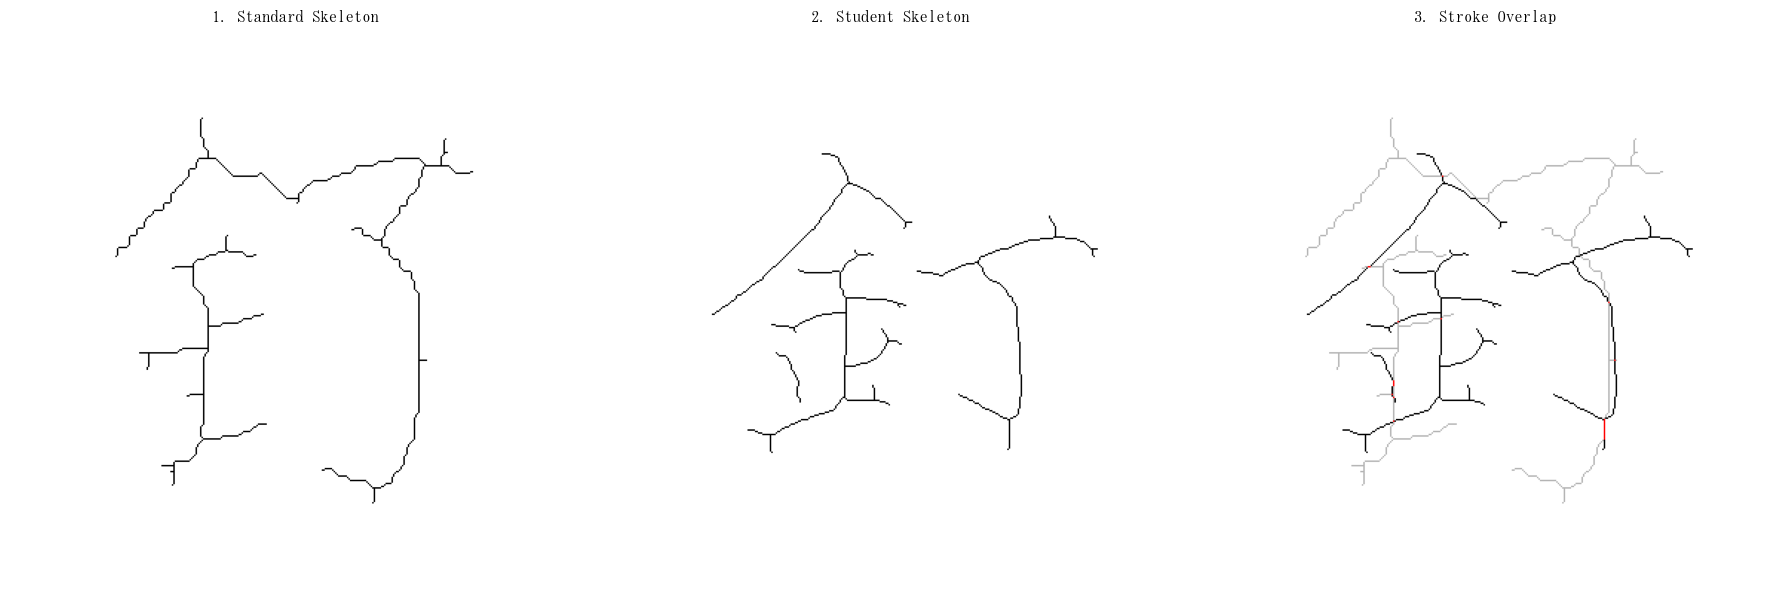

In [31]:
# example
result_skeleton = compare_skeleton_and_save(user_upload_path, match_img_path, processed_dir)
# skeleton_align_score
match_score = result_skeleton['score']

## overlap visualization

In [32]:
def compare_stroke_and_save(
    user_upload_path,
    match_img_path,
    process_dir,
    canvas_size='auto',
    padding_ratio=0.15,
    tolerance_ratio=0.02,
    search_radius_ratio=0.03,
    show=True,
):
    """Compare two images using stroke-level overlap and save the result."""
    from pathlib import Path
    import time

    def _normalize_path(path_like):
        return str(Path(str(path_like).replace('\\', '/')))

    def _make_stroke_vis(binary_img):
        vis = np.ones((*binary_img.shape, 3), dtype=np.uint8) * 255
        vis[binary_img > 0] = [0, 0, 0]
        return vis

    process_path = Path(process_dir)
    process_path.mkdir(parents=True, exist_ok=True)

    std_path = _normalize_path(match_img_path)
    stu_path = _normalize_path(user_upload_path)

    std_aligned, stu_aligned, _, score, canvas_size, total_dx, total_dy, align_score = generate_normalized_evaluation(
        std_path=std_path,
        stu_path=stu_path,
        canvas_size=canvas_size,
        padding_ratio=padding_ratio,
        tolerance_ratio=tolerance_ratio,
        search_radius_ratio=search_radius_ratio,
    )

    std_bin = (std_aligned > 0).astype(np.uint8)
    stu_bin = (stu_aligned > 0).astype(np.uint8)
    overlap = np.logical_and(std_bin > 0, stu_bin > 0)

    std_vis = _make_stroke_vis(std_bin)
    stu_vis = _make_stroke_vis(stu_bin)

    overlap_vis = np.ones((*std_bin.shape, 3), dtype=np.uint8) * 255
    overlap_vis[std_bin > 0] = [180, 180, 180]
    overlap_vis[stu_bin > 0] = [0, 0, 0]
    overlap_vis[overlap] = [255, 0, 0]

    timestamp = time.strftime('%Y%m%d_%H%M%S')
    overlap_img_path = process_path / 'stroke_overlap.png'
    user_extract_path = process_path / 'user_extract.png'
    master_extract_path = process_path / 'master_extract.png'

    cv2.imwrite(str(overlap_img_path), overlap_vis)
    cv2.imwrite(str(user_extract_path), stu_vis)
    cv2.imwrite(str(master_extract_path), std_vis)

    print('=' * 60)
    print(f'Scale-Normalized Alignment Score: {score:.2f} / 100')
    print(f'📐 Auto Canvas Size: {canvas_size} x {canvas_size}')
    print(f'🧭 Align Shift: dx={total_dx}, dy={total_dy}')
    print(f'🔎 Search Match Score: {align_score:.4f}')
    print('=' * 60)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(std_vis)
    axes[0].set_title('1. Standard Stroke')
    axes[0].axis('off')

    axes[1].imshow(stu_vis)
    axes[1].set_title('2. Student Stroke')
    axes[1].axis('off')

    axes[2].imshow(overlap_vis)
    axes[2].set_title('3. Stroke Overlap')
    axes[2].axis('off')

    plt.tight_layout()
    if show:
        plt.show()
    plt.close(fig)

    result = {
        'score': score,
        'align_score': align_score,
        'canvas_size': canvas_size,
        'total_dx': total_dx,
        'total_dy': total_dy,
        'user_upload_path': stu_path,
        'match_img_path': std_path,
        'overlap_img_path': str(overlap_img_path),
        'user_extract_path': str(user_extract_path),
        'master_extract_path': str(master_extract_path),
        'timestamp': timestamp,
    }

    print(f'Saved stroke overlap to: {overlap_img_path}')
    print(f'Saved user extract to: {user_extract_path}')
    print(f'Saved master extract to: {master_extract_path}')
    return result


# example
# result_stroke = compare_stroke_and_save(user_upload_path, match_img_path, processed_dir)

Scale-Normalized Alignment Score: 9.00 / 100
📐 Auto Canvas Size: 384 x 384
🧭 Align Shift: dx=13, dy=-7
🔎 Search Match Score: 0.4199


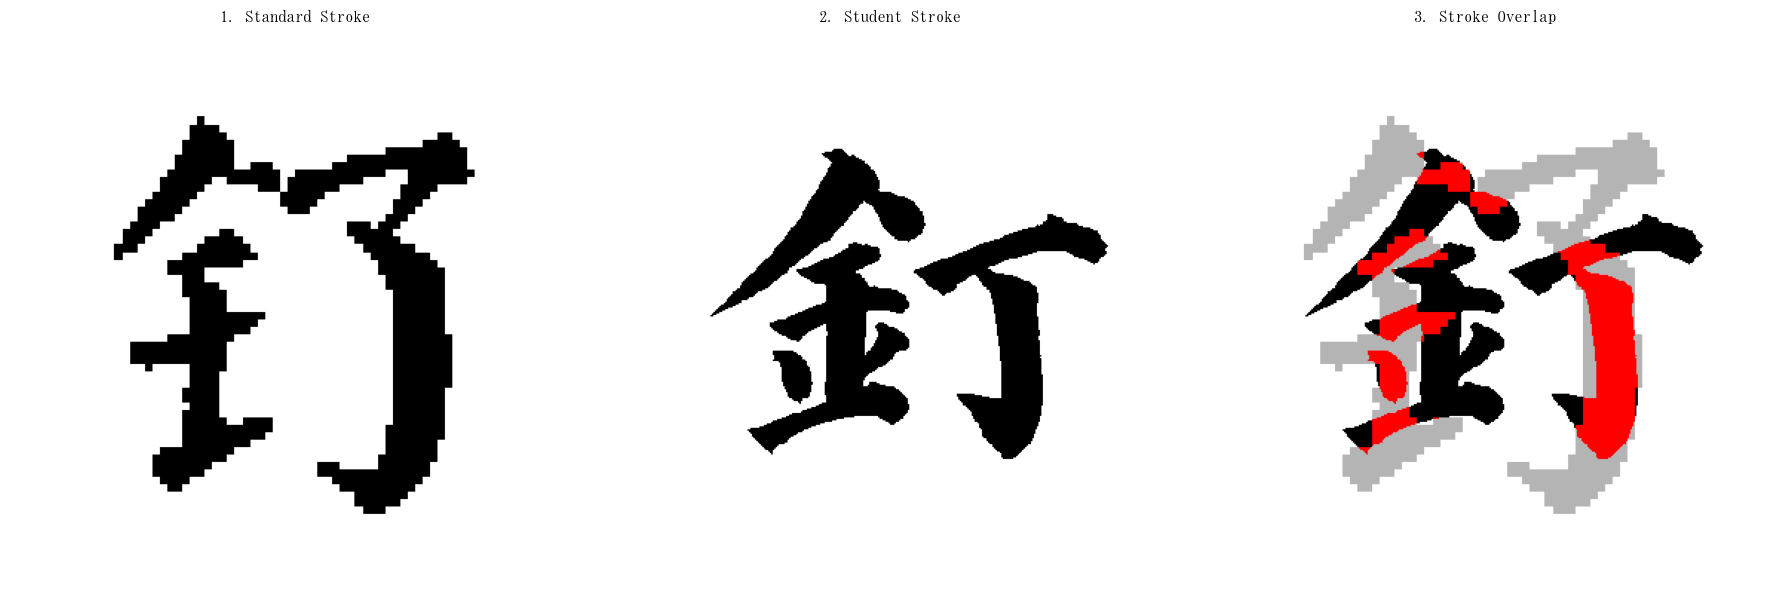

Saved stroke overlap to: temp_pic/processed_260426_203134/stroke_overlap.png
Saved user extract to: temp_pic/processed_260426_203134/user_extract.png
Saved master extract to: temp_pic/processed_260426_203134/master_extract.png


In [33]:
# example
result_stroke = compare_stroke_and_save(user_upload_path, match_img_path, processed_dir)


# 图片embedding

## 先清理显存

## 图片 RAG

In [34]:
rag_folder_path_train = f"calli-kaggle/data/data/train/{user_set_style}"
rag_folder_path_test = f"calli-kaggle/data/data/test/{user_set_style}"

print("train 搜索文件夹:", rag_folder_path_train)
print("test 搜索文件夹:", rag_folder_path_test)

train 搜索文件夹: calli-kaggle/data/data/train/yzq
test 搜索文件夹: calli-kaggle/data/data/test/yzq


In [35]:
from pathlib import Path
import json
import torch

# 默认用当前识别到的大师名；如未设置则手动输入
name = user_set_style if 'user_set_style' in globals() and user_set_style else input("请输入大师名称: ").strip()

def _resolve_embedding_file(root_dir: Path, style_name: str, suffix: str):
    """支持两种结构:
    1) embedding/train/{style}.pt
    2) embedding/train/{style}/{style}.pt
    """
    candidates = [
        root_dir / f"{style_name}{suffix}",
        root_dir / style_name / f"{style_name}{suffix}",
    ]
    for p in candidates:
        if p.exists():
            return p
    # 最后兜底：递归查找文件名完全匹配
    found = list(root_dir.rglob(f"{style_name}{suffix}"))
    return found[0] if found else None

train_root = Path("embedding/train")
test_root = Path("embedding/test")
train_pt = _resolve_embedding_file(train_root, name, ".pt")
test_pt = _resolve_embedding_file(test_root, name, ".pt")
train_paths_json = _resolve_embedding_file(train_root, name, "_paths.json")
test_paths_json = _resolve_embedding_file(test_root, name, "_paths.json")

missing_files = [
    label for label, p in [
        ("train_pt", train_pt),
        ("test_pt", test_pt),
        ("train_paths_json", train_paths_json),
        ("test_paths_json", test_paths_json),
    ] if p is None
]
if missing_files:
    raise FileNotFoundError(
        "未找到以下 embedding 文件键: " + ", ".join(missing_files) + f"（style={name}）"
    )

train_emb = torch.load(train_pt, map_location="cpu")
test_emb = torch.load(test_pt, map_location="cpu")

with open(train_paths_json, "r", encoding="utf-8") as f:
    train_paths = json.load(f)
with open(test_paths_json, "r", encoding="utf-8") as f:
    test_paths = json.load(f)

train_embedding_result = {
    "image_paths": train_paths,
    "embeddings": train_emb,
}
test_embedding_result = {
    "image_paths": test_paths,
    "embeddings": test_emb,
}

print(f"Loaded train embedding: {len(train_paths)} | {train_pt}")
print(f"Loaded test embedding: {len(test_paths)} | {test_pt}")

Loaded train embedding: 5405 | embedding/train/yzq/yzq.pt
Loaded test embedding: 1351 | embedding/test/yzq/yzq.pt


In [36]:
from pathlib import Path
import torch
import torch.nn.functional as F
from PIL import Image

# 你可以改这个值
top_k = 5


def _normalize_path(path_like):
    return Path(str(path_like).replace("\\", "/"))


def _to_relative_path(path_str):
    p = _normalize_path(path_str)
    try:
        return p.resolve().relative_to(Path.cwd().resolve()).as_posix()
    except Exception:
        return p.as_posix()


def _embed_single_image(image_path):
    """Fallback: only used when query image is not in saved embedding DB."""
    if "model_rag" not in globals() or "processor_rag" not in globals():
        raise RuntimeError(
            "query 图片不在已保存 embedding 中，且 model_rag/processor_rag 未加载，无法编码 query。"
        )

    model_rag.eval()
    model_device = next(model_rag.parameters()).device

    image_path = _normalize_path(image_path)
    image = Image.open(image_path).convert("RGB")
    inputs = processor_rag(images=image, return_tensors="pt")
    inputs = {k: v.to(model_device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model_rag(**inputs)
        emb = outputs.last_hidden_state[:, 0, :].detach().cpu()

    return emb


def _get_query_embedding_from_db(match_img_path, merged_paths, merged_emb):
    query_rel = _to_relative_path(match_img_path)
    rel_paths = [_to_relative_path(p) for p in merged_paths]
    if query_rel in rel_paths:
        idx = rel_paths.index(query_rel)
        return merged_emb[idx:idx + 1], query_rel
    return None, query_rel


def search_mixed_topk(match_img_path, train_embedding_result, test_embedding_result, top_k=5):
    train_paths = train_embedding_result["image_paths"]
    test_paths = test_embedding_result["image_paths"]
    train_emb = train_embedding_result["embeddings"]
    test_emb = test_embedding_result["embeddings"]

    merged_paths = train_paths + test_paths
    if train_emb.shape[0] > 0 and test_emb.shape[0] > 0:
        merged_emb = torch.cat([train_emb, test_emb], dim=0)
    elif train_emb.shape[0] > 0:
        merged_emb = train_emb
    else:
        merged_emb = test_emb

    if len(merged_paths) == 0 or merged_emb.shape[0] == 0:
        return []

    query_emb, query_rel = _get_query_embedding_from_db(match_img_path, merged_paths, merged_emb)
    if query_emb is None:
        query_emb = _embed_single_image(match_img_path)

    # 先多取一些，后面去掉 query 本身
    k_for_search = min(top_k + 1, merged_emb.shape[0])

    query_norm = F.normalize(query_emb, p=2, dim=1)
    db_norm = F.normalize(merged_emb, p=2, dim=1)
    sims = (query_norm @ db_norm.T).squeeze(0)
    values, indices = torch.topk(sims, k=k_for_search)

    mixed_results = []
    train_count = len(train_paths)
    for score, idx in zip(values.tolist(), indices.tolist()):
        rel_path = _to_relative_path(merged_paths[idx])
        if rel_path == query_rel:
            continue

        split = "train" if idx < train_count else "test"
        mixed_results.append({
            "relative_path": rel_path,
            "similarity": float(score),
            "split": split,
        })

        if len(mixed_results) >= top_k:
            break

    return mixed_results

In [37]:
mixed_topk_results = search_mixed_topk(
    match_img_path,
    train_embedding_result,
    test_embedding_result,
    top_k=top_k_similar,
)

print("\nmixed top-k:")
print(mixed_topk_results)


mixed top-k:
[{'relative_path': 'calli-kaggle/data/data/train/yzq/3726.jpg', 'similarity': 0.9789584875106812, 'split': 'train'}, {'relative_path': 'calli-kaggle/data/data/train/yzq/2923.jpg', 'similarity': 0.9762090444564819, 'split': 'train'}, {'relative_path': 'calli-kaggle/data/data/train/yzq/0543.jpg', 'similarity': 0.9761891961097717, 'split': 'train'}]


In [38]:
import shutil
from pathlib import Path


def copy_topk_images_to_processed_dir(mixed_topk_results, processed_dir, prefix="similar_top"):
    """Copy retrieved top-k images into processed_dir as similar_top_i.*"""
    out_dir = Path(processed_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    saved_paths = []
    for i, item in enumerate(mixed_topk_results, start=1):
        src = Path(item["relative_path"])
        if not src.exists():
            src = Path.cwd() / item["relative_path"]

        if not src.exists():
            print(f"跳过不存在文件: {item['relative_path']}")
            continue

        dst = out_dir / f"{prefix}_{i}{src.suffix.lower()}"
        shutil.copy2(src, dst)
        saved_paths.append(str(dst))

    return saved_paths

In [39]:
# 选择所有的top-k, 展示图片
def display_topk_images(mixed_topk_results, top_k=5):
    fig, axes = plt.subplots(1, top_k, figsize=(4 * top_k, 4))
    for i in range(top_k):
        if i < len(mixed_topk_results):
            img_path = mixed_topk_results[i]["relative_path"]
            sim_score = mixed_topk_results[i]["similarity"]
            split = mixed_topk_results[i]["split"]

            img = Image.open(img_path).convert("RGB")
            axes[i].imshow(img)
            axes[i].set_title(f"{split}\n{sim_score:.4f}")
        else:
            axes[i].axis("off")

        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

In [40]:
saved_similar_paths = copy_topk_images_to_processed_dir(mixed_topk_results, processed_dir)
print("已复制文件:")
print(saved_similar_paths)

已复制文件:
['temp_pic/processed_260426_203134/similar_top_1.jpg', 'temp_pic/processed_260426_203134/similar_top_2.jpg', 'temp_pic/processed_260426_203134/similar_top_3.jpg']


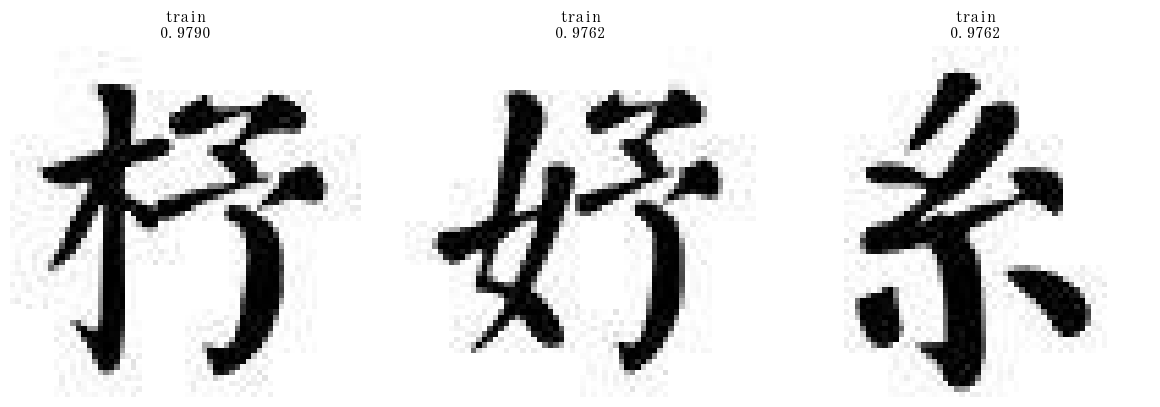

In [41]:
display_topk_images(mixed_topk_results, top_k=top_k_similar)

# LLM feedback

continue model_b

In [42]:
# 从 processed_dir 里导入图片，并分别存好（不做 LLM 输入整合）
processed_dir_path = Path(processed_dir)


def _load_if_exists(p: Path):
    if p.exists():
        return Image.open(p).convert("RGB")
    return None


def _load_similar_by_index(i: int):
    candidates = sorted(processed_dir_path.glob(f"similar_top_{i}.*"))
    if candidates:
        return _load_if_exists(candidates[0]), str(candidates[0])
    return None, None


# 1) 固定命名图片
concentration_path = processed_dir_path / "concentration.jpg"
master_extract_path = processed_dir_path / "master_extract.png"
overlap_skeleton_path = processed_dir_path / "overlap_skeleton.png"
stroke_overlap_path = processed_dir_path / "stroke_overlap.png"
user_extract_path = processed_dir_path / "user_extract.png"

image_concentration = _load_if_exists(concentration_path)
image_master_extract = _load_if_exists(master_extract_path)
image_overlap_skeleton = _load_if_exists(overlap_skeleton_path)
image_stroke_overlap = _load_if_exists(stroke_overlap_path)
image_user_extract = _load_if_exists(user_extract_path)

# 2) similar top-k 图片（按 top_k_similarity 动态创建变量）
n_similar = int(globals().get("top_k_similarity", globals().get("top_k_similar", 3)))

for i in range(1, n_similar + 1):
    img_obj, img_path = _load_similar_by_index(i)
    globals()[f"image_similar_top_{i}"] = img_obj
    globals()[f"similar_top_{i}_path"] = img_path

print("固定图片加载状态:")
print("concentration:", image_concentration is not None)
print("master_extract:", image_master_extract is not None)
print("overlap_skeleton:", image_overlap_skeleton is not None)
print("stroke_overlap:", image_stroke_overlap is not None)
print("user_extract:", image_user_extract is not None)

print("\nsimilar 图片加载状态:")
for i in range(1, n_similar + 1):
    obj_img = globals().get(f"image_similar_top_{i}")
    image_path = globals().get(f"similar_top_{i}_path")
    print(f"similar_top_{i}:", obj_img is not None, "|", image_path)

# 检验图片加载是否成功
print("image_concentration loaded:", image_concentration is not None)
print("image_master_extract loaded:", image_master_extract is not None)
print("image_overlap_skeleton loaded:", image_overlap_skeleton is not None)
print("image_stroke_overlap loaded:", image_stroke_overlap is not None)
print("image_user_extract loaded:", image_user_extract is not None)
for i in range(1, n_similar + 1):
    print(f"image_similar_top_{i} loaded:", globals().get(f"image_similar_top_{i}") is not None)

固定图片加载状态:
concentration: True
master_extract: True
overlap_skeleton: True
stroke_overlap: True
user_extract: True

similar 图片加载状态:
similar_top_1: True | temp_pic/processed_260426_203134/similar_top_1.jpg
similar_top_2: True | temp_pic/processed_260426_203134/similar_top_2.jpg
similar_top_3: True | temp_pic/processed_260426_203134/similar_top_3.jpg
image_concentration loaded: True
image_master_extract loaded: True
image_overlap_skeleton loaded: True
image_stroke_overlap loaded: True
image_user_extract loaded: True
image_similar_top_1 loaded: True
image_similar_top_2 loaded: True
image_similar_top_3 loaded: True


In [43]:
# from transformers import AutoProcessor, AutoModelForImageTextToText
# processor_b = AutoProcessor.from_pretrained("Qwen/Qwen3-VL-8B-Instruct")
# model_b = AutoModelForImageTextToText.from_pretrained("Qwen/Qwen3-VL-8B-Instruct")
# model_b.to(device)

In [44]:
user_set_style_master = master_match_dict.get(user_set_style, "未知大师")
print(f"当前设置的大师是: {user_set_style_master}")

当前设置的大师是: 颜真卿


In [ ]:
prompt_1 = f'''
The style of the master is {user_set_style_master}
Can you analyze the gap between the student and the master, only focus on the character's structure itself, and give a score from 0 to 10?
'''
messages = [
    {
        "role": "user",
        "content": [
            {"type": "text", "text": "the image_1 is the master's work"},
            {"type": "image", "name": "image_1", "image": image_master_extract},
            {"type": "text", "text": "the image_2 is the student's work"},
            {"type": "image", "name": "image_2", "image": image_user_extract},
            {"type": "text", "text": "the image_3 is the skeleton overlap of the master and student"},
            {"type": "image", "name": "image_3", "image": image_overlap_skeleton},
            {"type": "text", "text": "the image_4 is the stroke overlap of the master and student"},
            {"type": "image", "name": "image_4", "image": image_stroke_overlap},
            {"type": "text", "text": prompt_1},
        ]
    },
]

inputs = processor_b.apply_chat_template(
	messages,
	add_generation_prompt=True,
	tokenize=True,
	return_dict=True,
	return_tensors="pt",
).to(model_b.device)

outputs = model_b.generate(**inputs, max_new_tokens=800)

response_1 = processor_b.decode(outputs[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True)
print("Response 1:")
print(response_1)

Response 1:
Based on a focused analysis of the character's structure alone, here is the evaluation:

The student's work shows a clear attempt to emulate the master's style, particularly the bold, angular, and robust strokes characteristic of Yan Zhenqing. However, the structure reveals several key gaps.

*   **Proportional Imbalance:** The student's character has an uneven distribution of weight. The left side (the "金" radical) is overly heavy and bulky, while the right side (the "钅" component) is comparatively light and appears to be "floating" or detached. This disrupts the visual equilibrium that the master achieves.
*   **Component Alignment:** The "金" radical is not vertically aligned with the top of the "钅" component. In the master's work, the vertical strokes and horizontal elements are meticulously aligned to create a unified, stable structure. The student's version appears slightly askew, which is a significant structural flaw.
*   **Internal Structure:** The master's characte

In [ ]:
prompt_2 = f'''
The style of the master is {user_set_style_master};
The character is {recog_char};
Here are some similar works retrieved with similar structure, please analyze the writen skill of these characters,
and give advices of how to write better.
'''
messages = [
    {
        "role": "user",
        "content": [
            {"type": "text", "text": "the images is the master's similar works"},
            {"type": "image", "name": "image_1", "image": image_master_extract},
            {"type": "image", "name": "image_2", "image": image_similar_top_1},
            {"type": "image", "name": "image_3", "image": image_similar_top_2},
            {"type": "image", "name": "image_4", "image": image_similar_top_3},
            {"type": "text", "text": prompt_2},
        ]
    },
]
inputs = processor_b.apply_chat_template(
	messages,
	add_generation_prompt=True,
	tokenize=True,
	return_dict=True,
	return_tensors="pt",
).to(model_b.device)

outputs = model_b.generate(**inputs, max_new_tokens=800)

response_2 = processor_b.decode(outputs[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True)
print("Response 2:")
print(response_2)

Response 2:
Thank you for providing the images and context. Based on the master’s style being **Yan Zhenqing** (颜真卿), and the character being **钉 (dìng)**, here is an analysis of the similar works and advice for writing this character better.

---

### **Analysis of the Similar Works**

The four characters you provided — 钉, 柔, 妙, 系 — are all examples of **Yan Zhenqing-style regular script (楷书)**. Yan Zhenqing’s style is characterized by:

- **Bold, robust, and powerful strokes** — often described as “like a mountain standing firm.”
- **Clear, deliberate structure** — each stroke is intentional and balanced.
- **Strong verticals and horizontal lines** — giving the characters a grounded, stable appearance.
- **Emphasis on the “bone” (骨) and “muscle” (肉)** — strong structure with appropriate spacing and weight.
- **Slightly angular, expressive forms** — not overly rounded, but with a sense of movement and energy.

Let’s analyze each character briefly:

1. **钉 (dìng)** — The character “钉” 